['epoch', 'train_loss', 'validation_loss', 'validation_dice', 'validation_iou', 'validation_precision', 'validation_recall', 'validation_specificity', 'validation_gt_positive_fraction', 'validation_predicted_positive_fraction', 'lr_sam_adapter', 'lr_task', 'elapsed_hours']
 epoch  train_loss  validation_loss  validation_dice  validation_iou  validation_precision  validation_recall  validation_specificity  validation_gt_positive_fraction  validation_predicted_positive_fraction  lr_sam_adapter  lr_task  elapsed_hours
     1    4.261734         4.066241         0.064610        0.033383              0.220464           0.037851                0.977740                         0.142605                                0.024484        0.000033 0.000100       0.162619
     2    4.176758         4.027712         0.201025        0.111744              0.282107           0.156146                0.933911                         0.142605                                0.078932        0.000067 0.000200 

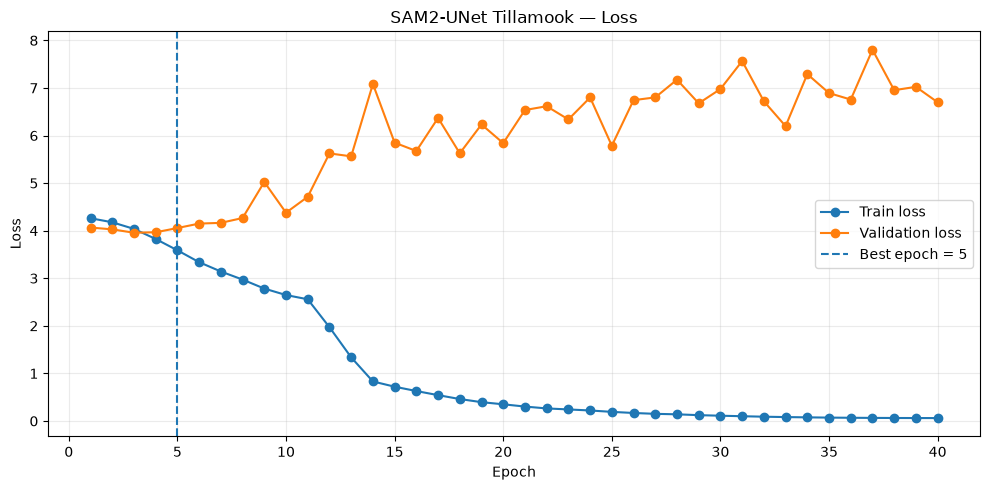

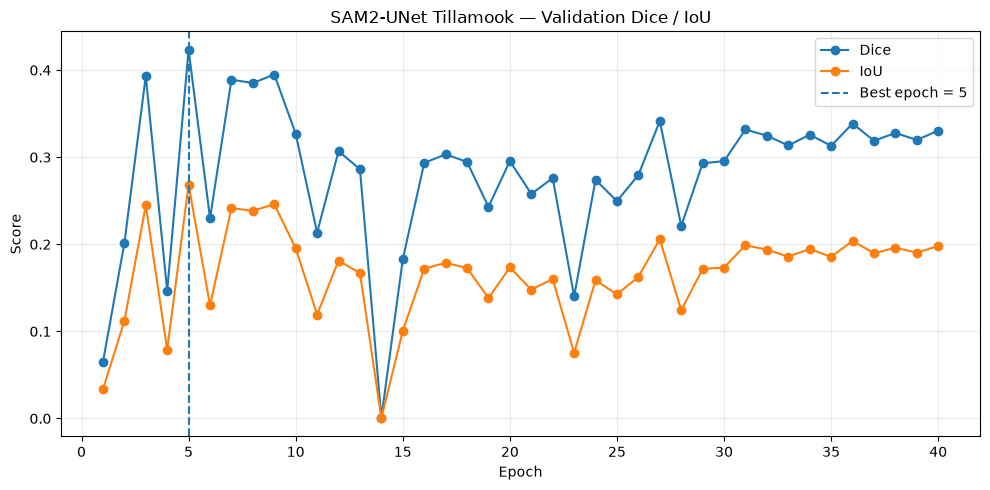

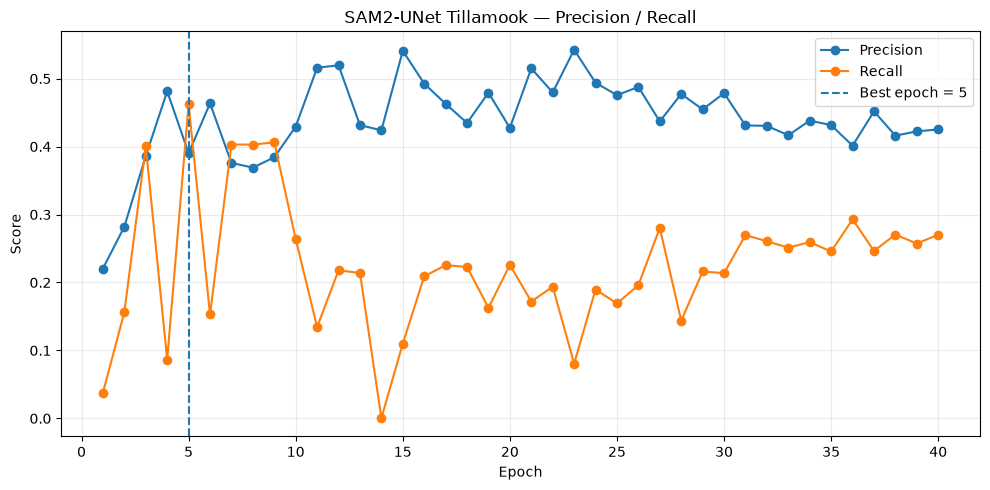

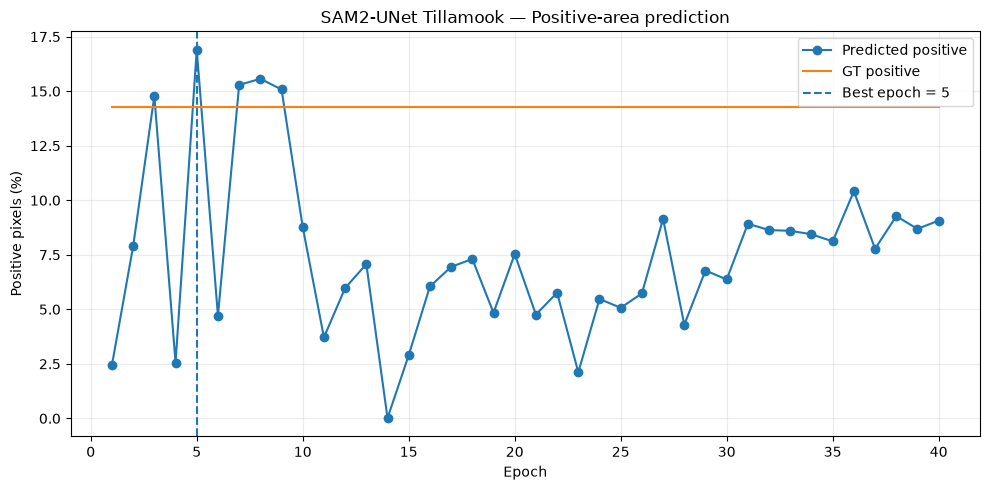

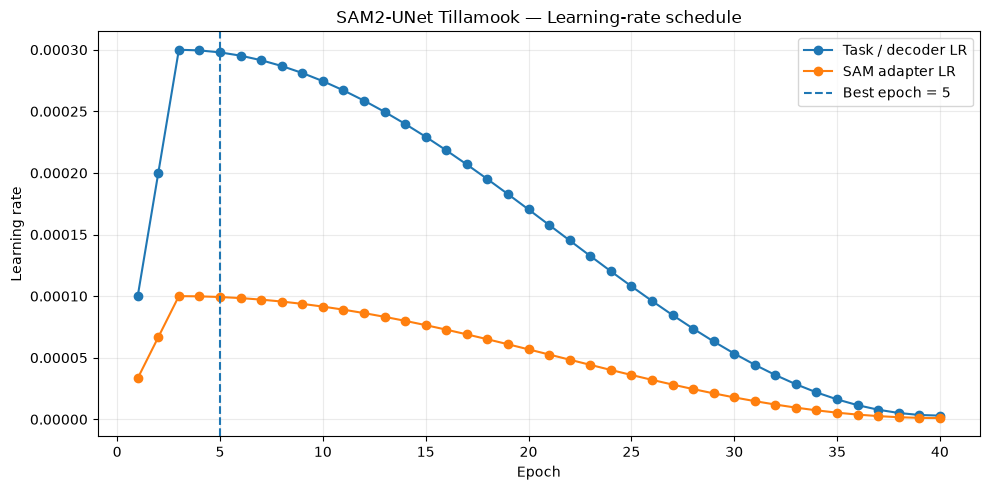

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

p = r".\phase5_sam2unet_7ch\history.csv"
df = pd.read_csv(p)

print(df.columns.tolist())
print(df.to_string(index=False))

best = df.loc[df["validation_dice"].idxmax()]

print("\nBEST EPOCH")
print(best[[
    "epoch",
    "train_loss",
    "validation_loss",
    "validation_dice",
    "validation_iou",
    "validation_precision",
    "validation_recall",
    "validation_specificity",
    "validation_predicted_positive_fraction",
    "lr_sam_adapter",
    "lr_task",
]])

# 1. Train / validation loss
plt.figure(figsize=(10, 5))
plt.plot(df["epoch"], df["train_loss"], marker="o", label="Train loss")
plt.plot(df["epoch"], df["validation_loss"], marker="o", label="Validation loss")
plt.axvline(best["epoch"], linestyle="--", label=f"Best epoch = {int(best['epoch'])}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SAM2-UNet Tillamook — Loss")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Dice / IoU
plt.figure(figsize=(10, 5))
plt.plot(df["epoch"], df["validation_dice"], marker="o", label="Dice")
plt.plot(df["epoch"], df["validation_iou"], marker="o", label="IoU")
plt.axvline(best["epoch"], linestyle="--", label=f"Best epoch = {int(best['epoch'])}")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("SAM2-UNet Tillamook — Validation Dice / IoU")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Precision / recall
plt.figure(figsize=(10, 5))
plt.plot(df["epoch"], df["validation_precision"], marker="o", label="Precision")
plt.plot(df["epoch"], df["validation_recall"], marker="o", label="Recall")
plt.axvline(best["epoch"], linestyle="--", label=f"Best epoch = {int(best['epoch'])}")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("SAM2-UNet Tillamook — Precision / Recall")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Positive-area prediction
plt.figure(figsize=(10, 5))
plt.plot(
    df["epoch"],
    100 * df["validation_predicted_positive_fraction"],
    marker="o",
    label="Predicted positive",
)
plt.plot(
    df["epoch"],
    100 * df["validation_gt_positive_fraction"],
    label="GT positive",
)
plt.axvline(best["epoch"], linestyle="--", label=f"Best epoch = {int(best['epoch'])}")
plt.xlabel("Epoch")
plt.ylabel("Positive pixels (%)")
plt.title("SAM2-UNet Tillamook — Positive-area prediction")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# 5. Learning rates
plt.figure(figsize=(10, 5))
plt.plot(df["epoch"], df["lr_task"], marker="o", label="Task / decoder LR")
plt.plot(df["epoch"], df["lr_sam_adapter"], marker="o", label="SAM adapter LR")
plt.axvline(best["epoch"], linestyle="--", label=f"Best epoch = {int(best['epoch'])}")
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("SAM2-UNet Tillamook — Learning-rate schedule")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()